In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier

from pathlib import Path

DATA = Path("../data")
sessions = pd.read_csv(DATA / 'ml_sessions.csv')

In [2]:
sessions.head()

df = sessions.copy()

In [3]:
X = df[['grid_load_index', 'station_age_years', 'ambient_temp_c']]
y = df['failed']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.25,
    random_state = 42,
    stratify = y,
)

model = LogisticRegression().fit(X_train, y_train)

baseline = DummyClassifier(strategy = 'most_frequent').fit(X_train, y_train)

print("test rows: ", len(y_test), "real failures: ", int(y_test.sum()))
print("model accuracy   :", round(model.score(X_test, y_test), 4))
print("Baseline accuracy: ",round(baseline.score(X_test, y_test), 4))

test rows:  11250 real failures:  950
model accuracy   : 0.9156
Baseline accuracy:  0.9156


In [4]:
from sklearn.metrics import confusion_matrix

pred = model.predict(X_test)
cm = confusion_matrix(y_test, pred)
print(cm)

[[10300     0]
 [  950     0]]


In [5]:
tn = 10300
fn = 950

In [6]:
accuracy = tn / (fn + tn)

print(accuracy)

0.9155555555555556


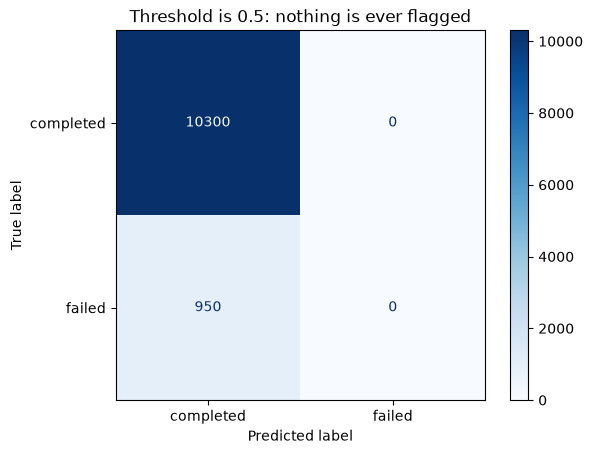

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test, pred, display_labels = ['completed', 'failed'], cmap = 'Blues',
    values_format = "d"                        ## Whole numbers
)

plt.title("Threshold is 0.5: nothing is ever flagged")
plt.show()

In [8]:
probs = model.predict_proba(X_test)

for prob_failed in probs[:, 1]:
    if prob_failed > 0.5:
        print("failed predictions exists")
    print("No prediction of failure")

No prediction of failure
No prediction of failure
No prediction of failure
No prediction of failure
No prediction of failure
No prediction of failure
No prediction of failure
No prediction of failure
No prediction of failure
No prediction of failure
No prediction of failure
No prediction of failure
No prediction of failure
No prediction of failure
No prediction of failure
No prediction of failure
No prediction of failure
No prediction of failure
No prediction of failure
No prediction of failure
No prediction of failure
No prediction of failure
No prediction of failure
No prediction of failure
No prediction of failure
No prediction of failure
No prediction of failure
No prediction of failure
No prediction of failure
No prediction of failure
No prediction of failure
No prediction of failure
No prediction of failure
No prediction of failure
No prediction of failure
No prediction of failure
No prediction of failure
No prediction of failure
No prediction of failure
No prediction of failure


In [9]:
from sklearn.metrics import f1_score, precision_score, recall_score

print("precision  :", precision_score(y_test, pred, zero_division = 0))
print("recall     :", recall_score(y_test, pred))
print("f1         :", f1_score(y_test, pred, zero_division = 0))

precision  : 0.0
recall     : 0.0
f1         : 0.0


In [10]:
probs = model.predict_proba(X_test)[:, 1]

print("threshold flagged precision recall")

for t in [0.5, 0.2, 0.15, 0.1, 0.07]:
    flag = (probs >= t).astype(int)
    
    p = precision_score(y_test, flag, zero_division = 0)
    r = recall_score(y_test, flag)
    print(f" Threshold: {t:.2f},  Flag: {flag.sum():5}, Precision: {p:.2f}, Recall: {r:.2f}")

threshold flagged precision recall
 Threshold: 0.50,  Flag:     0, Precision: 0.00, Recall: 0.00
 Threshold: 0.20,  Flag:   302, Precision: 0.20, Recall: 0.06
 Threshold: 0.15,  Flag:  1203, Precision: 0.19, Recall: 0.23
 Threshold: 0.10,  Flag:  3293, Precision: 0.14, Recall: 0.50
 Threshold: 0.07,  Flag:  5945, Precision: 0.12, Recall: 0.74


ROC-AUC: 0.6641


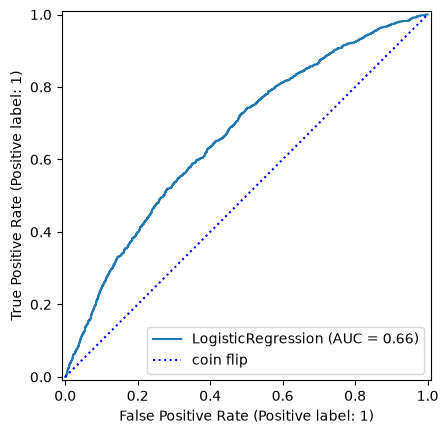

In [11]:
from sklearn.metrics import RocCurveDisplay, roc_auc_score

auc = roc_auc_score(y_test, probs)

print("ROC-AUC:", round(auc, 4))

RocCurveDisplay.from_predictions(y_test, probs, name = "LogisticRegression")
plt.plot([0,1], [0,1], linestyle = ":", color = 'blue', label = 'coin flip')
plt.legend()
plt.show()


In [12]:
rng = np.random.default_rng(0)
falied_p = rng.choice(probs[y_test.to_numpy() == 1], 200_000)
ok_p = rng.choice(probs[y_test.to_numpy() == 0], 200_000)

print("random pairs wher the failure ranks higher:", round((falied_p > ok_p).mean(), 4))
print("roc_auc_score                             :", round(auc, 4))

random pairs wher the failure ranks higher: 0.6639
roc_auc_score                             : 0.6641


## Average precision

average precision:  0.1447
failure rate     :  0.0844


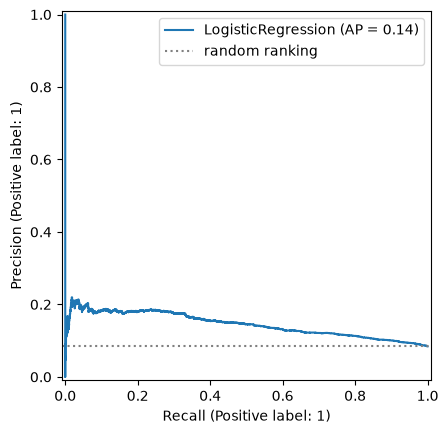

In [13]:
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score

ap = average_precision_score(y_test, probs)

print("average precision: ", round(ap, 4))
print("failure rate     : ", round(y_test.mean(), 4))

PrecisionRecallDisplay.from_predictions(y_test, probs, name = "LogisticRegression")
plt.axhline(y_test.mean(), linestyle = ":", color = 'grey', label = "random ranking")
plt.legend()
plt.show()


## Which metrics move with the threshold

In [14]:
for t in [0.5, 0.1]:
    flag = (probs >= t).astype(int)
    print(f"Threshold {t:.2f}: ROC-AUC {roc_auc_score(y_test, probs):.4f}   "
            f"AP {average_precision_score(y_test, probs):.4f}               "
            f"recall {recall_score(y_test, flag):.3f}")

    print(" Confusion matrix:", confusion_matrix(y_test, flag).ravel())

Threshold 0.50: ROC-AUC 0.6641   AP 0.1447               recall 0.000
 Confusion matrix: [10300     0   950     0]
Threshold 0.10: ROC-AUC 0.6641   AP 0.1447               recall 0.502
 Confusion matrix: [7484 2816  473  477]


## Choose the threshold based on the costs

In [15]:
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size = 0.25, random_state = 0, stratify = y_train)

model_v = LogisticRegression().fit(X_fit, y_fit)
probs_val = model_v.predict_proba(X_val)[:,1]
print("fit rows : ", len(X_fit), " Validation rows: ", len(X_val))
print("test rows (not used for choosing): ", len(X_test))


fit rows :  25312  Validation rows:  8438
test rows (not used for choosing):  11250


In [16]:
MISS_COST, CHECK_COST = 1500, 150

def total_cost(y_true, probs, t):
    tn, fp, fn, tp = confusion_matrix(y_true, (probs >=t).astype(int)).ravel()
    return fn * MISS_COST + (fp + tp) * CHECK_COST

val_costs = {}
for t in [0.5, 0.2, 0.15, 0.10, 0.07, 0.05]:
    val_costs[t] = total_cost(y_val, probs_val, t)
    print(f"threshold: {t:.2f}:    validation cost Rs {val_costs[t]:,}")

best = min(val_costs, key = val_costs.get)
print("Cheapest on validation: ", best)


threshold: 0.50:    validation cost Rs 1,069,500
threshold: 0.20:    validation cost Rs 1,029,150
threshold: 0.15:    validation cost Rs 932,700
threshold: 0.10:    validation cost Rs 907,350
threshold: 0.07:    validation cost Rs 953,850
threshold: 0.05:    validation cost Rs 1,089,900
Cheapest on validation:  0.1
